In [2]:
import librosa
import librosa.display
import numpy as np
import os
import soundfile as sf
from pydub import AudioSegment
import matplotlib.pyplot as plt

### Single audio processing

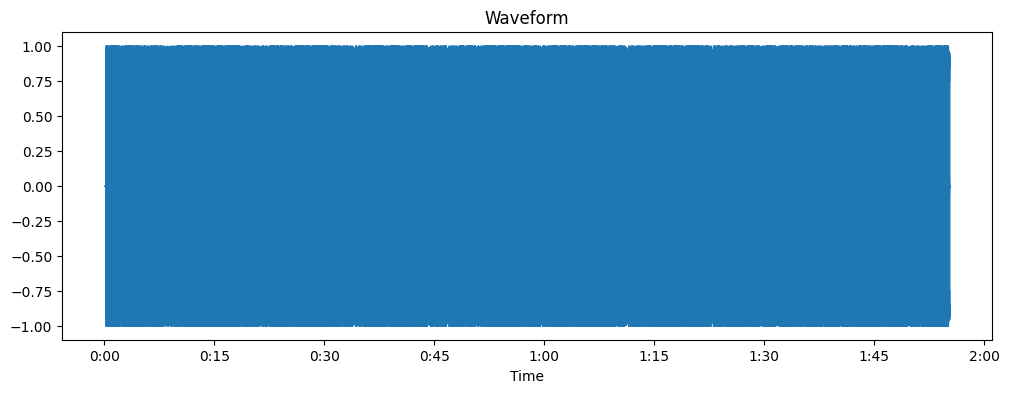

In [3]:
file_path = "/home/kar/Projects/EEND_SelfAttention/EEND_SelfAttention/data/test_data/0.wav"  # 테스트할 파일 경로
y, sr = librosa.load(file_path, sr=None)

# 오디오 파형 출력
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()


### STFT implement

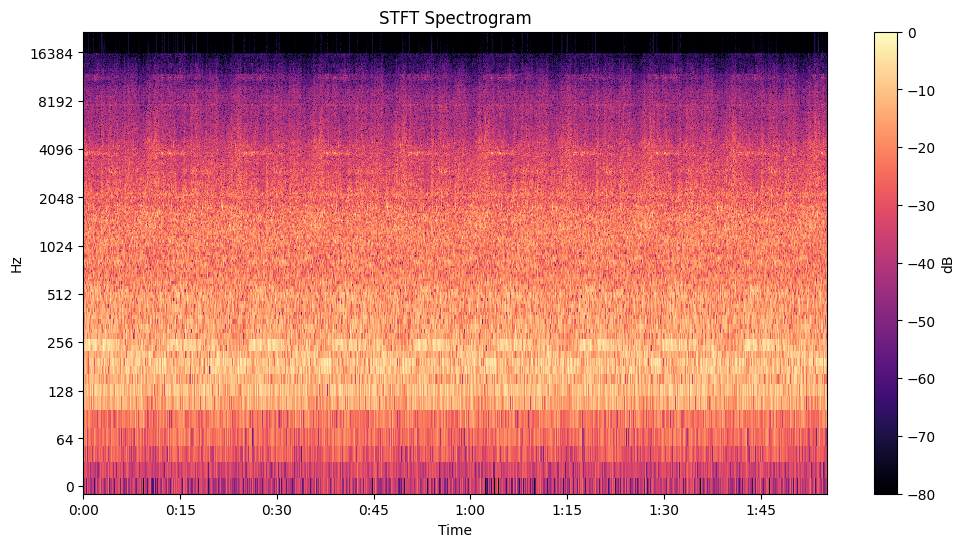

In [4]:
D = librosa.stft(y)
magnitude, _ = librosa.magphase(D)

# STFT 출력
plt.figure(figsize=(12, 6))
librosa.display.specshow(librosa.amplitude_to_db(magnitude, ref=np.max), sr=sr, hop_length=512, x_axis='time', y_axis='log')
plt.colorbar(label="dB")
plt.title("STFT Spectrogram")
plt.show()


### Labeling

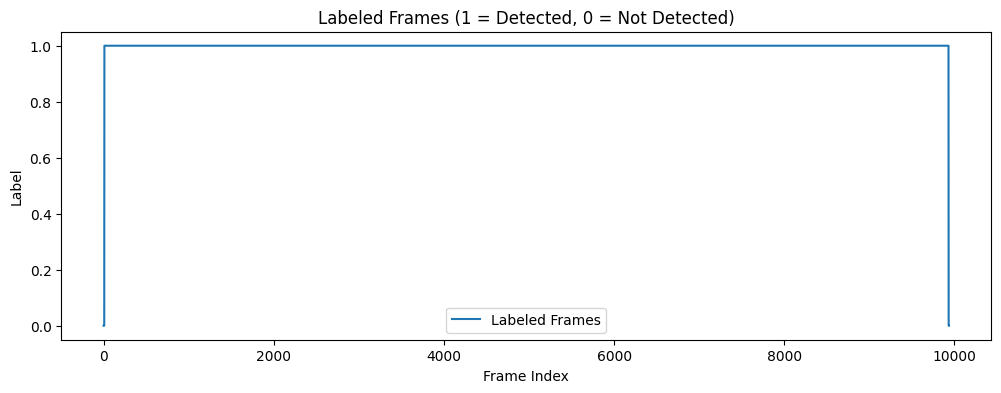

In [5]:
label_threshold = 0.1
labels = (np.mean(magnitude, axis=0) > label_threshold).astype(int)

# 라벨링된 부분 확인
plt.figure(figsize=(12, 4))
plt.plot(labels, label="Labeled Frames")
plt.title("Labeled Frames (1 = Detected, 0 = Not Detected)")
plt.xlabel("Frame Index")
plt.ylabel("Label")
plt.legend()
plt.show()

In [6]:
save_dir = "./test_data"
os.makedirs(save_dir, exist_ok=True)

base_name = os.path.basename(file_path).replace('.wav', '')
sf.write(os.path.join(save_dir, f"{base_name}_processed.wav"), y, sr)
np.save(os.path.join(save_dir, f"{base_name}_labels.npy"), labels)

print(f"Processed audio and labels saved in {save_dir}")

Processed audio and labels saved in ./test_data


In [7]:
file1 = "processed_audio/sample1_processed.wav"
file2 = "processed_audio/sample2_processed.wav"

audio1 = AudioSegment.from_wav(file1)
audio2 = AudioSegment.from_wav(file2)

merged_audio = audio1.overlay(audio2)
merged_audio.export("processed_audio/merged_audio.wav", format="wav")

print("Merged audio saved as 'processed_audio/merged_audio.wav'")


FileNotFoundError: [Errno 2] No such file or directory: 'processed_audio/sample1_processed.wav'

In [ ]:
labels1 = np.load("processed_audio/sample1_labels.npy")
labels2 = np.load("processed_audio/sample2_labels.npy")

merged_labels = np.vstack((labels1, labels2))
np.save("processed_audio/merged_labels.npy", merged_labels)

print("Merged labels saved as 'processed_audio/merged_labels.npy'")


In [ ]:
rttm_path = "processed_audio/merged_audio.rttm"
with open(rttm_path, "w") as f:
    for i in range(merged_labels.shape[1]):
        for j in range(merged_labels.shape[0]):
            if merged_labels[j, i]:
                f.write(f"SPEAKER merged_audio 1 {i} 0.1 <NA> <NA> Tank{j+1} <NA> <NA>\n")

print(f"RTTM file saved as '{rttm_path}'")
